In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:09<00:00, 187MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harishkumardatalab/food-image-classification-dataset/versions/1


In [ ]:
import os

# Check dataset folder structure
# Note: kagglehub usually downloads to a root folder; we need to find the directory containing image classes
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        if len(files) > 0:
            print(f'{subindent}{len(files)} files found.')
        if level >= 2: break # Only view basic structure

list_files(path)

1/
    Food Classification dataset/
        pav_bhaji/
            305 files found.


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Fix: Point to the actual directory containing the food categories
dataset_root = os.path.join(path, "Food Classification dataset")

all_images = []
all_labels = []

# Iterate through subdirectories (each directory is a label/food category)
if os.path.exists(dataset_root):
    for category in os.listdir(dataset_root):
        category_path = os.path.join(dataset_root, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(category_path, img_name))
                    all_labels.append(category)

# Check if data was found
if len(all_images) == 0:
    print("Error: No images found. Please check the directory structure.")
else:
    # Create a DataFrame for easier management
    df = pd.DataFrame({'image_path': all_images, 'label': all_labels})

    # Split the dataset into 80% Train and 20% Test
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Total images found: {len(df)}")
    print(f"Number of images in Train set: {len(train_df)}")
    print(f"Number of images in Test set: {len(test_df)}")

    # Display the first 5 rows of the Train set
    display(train_df.head())

Total images found: 23873
Number of images in Train set: 19098
Number of images in Test set: 4775


,image_path,label
9029,/root/.cache/kagglehub/datasets/harishkumardat...,Crispy Chicken
8859,/root/.cache/kagglehub/datasets/harishkumardat...,Crispy Chicken
6670,/root/.cache/kagglehub/datasets/harishkumardat...,Hot Dog
11078,/root/.cache/kagglehub/datasets/harishkumardat...,Taco
11201,/root/.cache/kagglehub/datasets/harishkumardat...,Taco


In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus}")
    # Optionally set GPU memory growth
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. Training will run on CPU.")

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


## Build and Train MobileNet Model

Now, let's build a MobileNetV2 model for image classification. We will use transfer learning by loading a pre-trained model and adding a new classification head.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Get the number of classes from the training data
num_classes = len(train_df['label'].unique())

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data
)

# Load the MobileNetV2 model with pre-trained ImageNet weights
# Exclude the top (classification) layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
history = model.fit(
    train_generator,
    epochs=10, # You can adjust the number of epochs
    validation_data=test_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)


Found 19098 validated image filenames belonging to 34 classes.
Found 4775 validated image filenames belonging to 34 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,604,578 (13.75 MB)

 Trainable params: 1,346,594 (5.14 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
173/597 ━━━━━━━━━━━━━━━━━━━━ 3:56 557ms/step - accuracy: 0.2757 - loss: 2.7159

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


597/597 ━━━━━━━━━━━━━━━━━━━━ 409s 651ms/step - accuracy: 0.5762 - loss: 1.5375 - val_accuracy: 0.7259 - val_loss: 0.9814
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 350s 586ms/step - accuracy: 0.7208 - loss: 0.9434 - val_accuracy: 0.7569 - val_loss: 0.8510
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 355s 595ms/step - accuracy: 0.7452 - loss: 0.8387 - val_accuracy: 0.7636 - val_loss: 0.8141
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 354s 593ms/step - accuracy: 0.7718 - loss: 0.7612 - val_accuracy: 0.7600 - val_loss: 0.8056
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 354s 593ms/step - accuracy: 0.7850 - loss: 0.7129 - val_accuracy: 0.7799 - val_loss: 0.7438
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 354s 594ms/step - accuracy: 0.7898 - loss: 0.6861 - val_accuracy: 0.7826 - val_loss: 0.7381
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 353s 591ms/step - accuracy: 0.7986 - loss: 0.6493 - val_accuracy: 0.7830 - val_loss: 0.7361
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 360s 604ms/step - accuracy: 0.8120 - loss: 0.61

## Training Results Summary

Let's evaluate the model on the test set and print the final accuracy and loss.

In [ ]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - accuracy: 0.7929 - loss: 0.7026
Test Loss: 0.7026
Test Accuracy: 0.7929


## Training History Plots

Visualize the training and validation accuracy and loss over epochs.

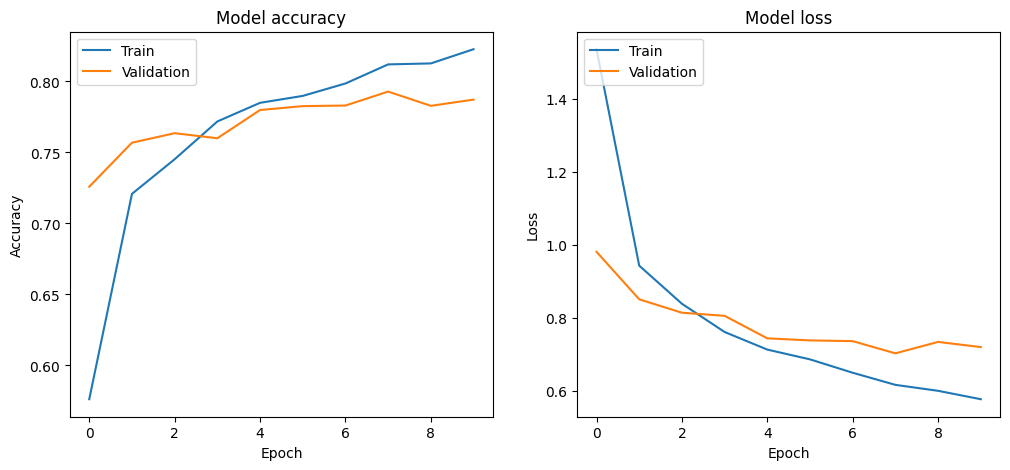

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()